## Figure 1: Spatial Distribution of Mutations in Tissue

This section simulates the spatial organization of mutations in tissue, inspired by the spatial transcriptomics approach used in the paper.

In the original study, tissue samples are divided into small spatial regions ("spots"), and each spot contains gene expression data. From this data, the researchers infer genetic mutations (copy number variations) and map them across the tissue.

In this simplified implementation:
- A 2D grid is used to represent tissue space
- Each point represents a cell or spatial spot
- Mutations are assigned to cells

Two conditions are simulated:
- **Benign tissue**: low mutation frequency, randomly distributed
- **Malignant tissue**: higher mutation frequency with spatial clustering

This corresponds to the paper’s spatial mapping of mutations across tissue sections, where malignant regions show more structured mutation patterns compared to benign regions.

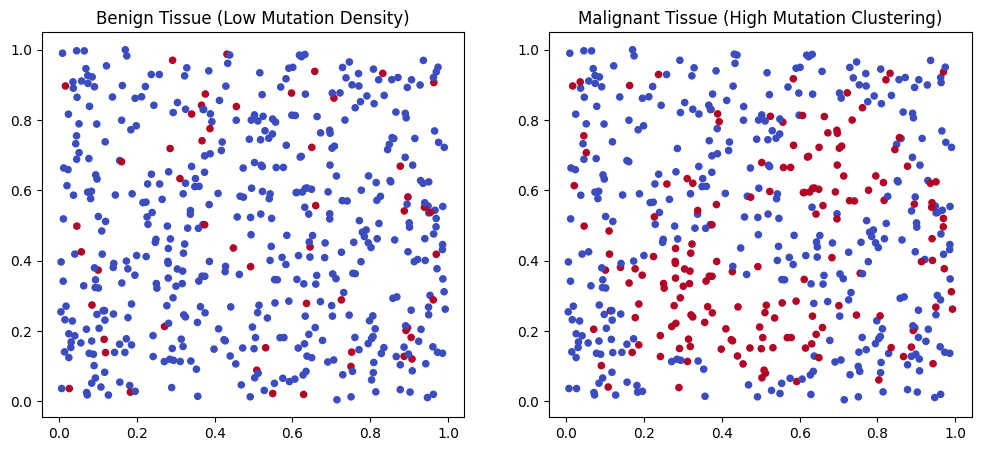

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

# Create tissue grid
n_cells = 500

# Generate coordinates
x = np.random.rand(n_cells)
y = np.random.rand(n_cells)

# --- BENIGN ---
# Few mutations (random scattered)
benign_mutations = np.random.choice([0, 1], size=n_cells, p=[0.9, 0.1])

# --- MALIGNANT ---
# More mutations + clustering
malignant_mutations = np.zeros(n_cells)

# Create clusters manually
cluster_centers = [(0.3, 0.3), (0.7, 0.7), (0.5, 0.2)]

for cx, cy in cluster_centers:
    distances = np.sqrt((x - cx)**2 + (y - cy)**2)
    malignant_mutations[distances < 0.15] = 1

# Add some random mutations too
random_noise = np.random.choice([0, 1], size=n_cells, p=[0.8, 0.2])
malignant_mutations = np.maximum(malignant_mutations, random_noise)

# --- PLOT ---
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Benign plot
axs[0].scatter(x, y, c=benign_mutations, cmap='coolwarm', s=20)
axs[0].set_title("Benign Tissue (Low Mutation Density)")

# Malignant plot
axs[1].scatter(x, y, c=malignant_mutations, cmap='coolwarm', s=20)
axs[1].set_title("Malignant Tissue (High Mutation Clustering)")

plt.show()

## Figure 2: Clonal Structure Identification using Clustering

In the paper, genetically similar cells are grouped into clonal populations based on inferred copy number variations (CNVs). These clones represent groups of cells that originate from a common mutated ancestor.

The study uses computational methods (such as inferCNV and hierarchical clustering) to identify these clonal groups and map them spatially.

In this simplified simulation:
- Only mutated cells are considered
- A clustering algorithm (DBSCAN) is applied
- Spatially close mutated cells are grouped into clusters

Each detected cluster represents a **clone**.

This replicates the core idea of the paper:
cells with similar mutation profiles and spatial proximity form clonal populations that expand within tissue.

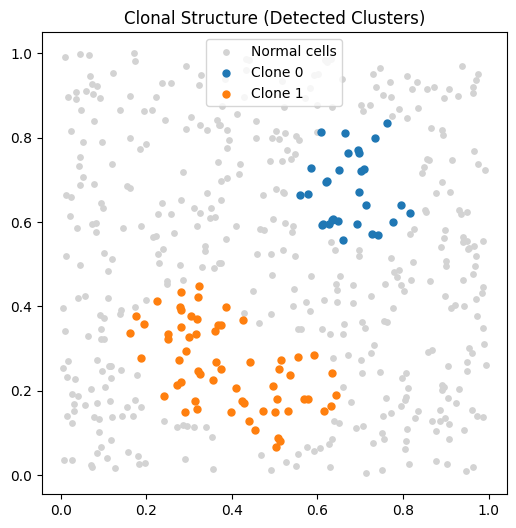

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

np.random.seed(42)

# Generate tissue points
n_cells = 500
x = np.random.rand(n_cells)
y = np.random.rand(n_cells)

points = np.column_stack((x, y))

# Simulate malignant mutations (clustered)
mutations = np.zeros(n_cells)

cluster_centers = [(0.3, 0.3), (0.7, 0.7), (0.5, 0.2)]

for cx, cy in cluster_centers:
    distances = np.sqrt((x - cx)**2 + (y - cy)**2)
    mutations[distances < 0.15] = 1

# Apply clustering ONLY on mutated cells
mutated_points = points[mutations == 1]

# DBSCAN clustering
clustering = DBSCAN(eps=0.08, min_samples=5).fit(mutated_points)
labels = clustering.labels_

# Plot
plt.figure(figsize=(6,6))

# Plot all cells (background)
plt.scatter(x, y, color='lightgrey', s=15, label="Normal cells")

# Plot clusters (clones)
for label in set(labels):
    if label == -1:
        continue  # skip noise
    cluster = mutated_points[labels == label]
    plt.scatter(cluster[:,0], cluster[:,1], s=25, label=f"Clone {label}")

plt.title("Clonal Structure (Detected Clusters)")
plt.legend()
plt.show()

## Figure 3: Spatial Mutation Density (Heterogeneity Map)

A key aspect of the paper is the concept of **spatial heterogeneity**, where mutation levels vary across different regions of tissue.

Instead of only identifying whether a mutation exists, the study also analyzes the intensity and distribution of genetic alterations across space.

In this simulation:
- Mutation intensity is modeled as a continuous value
- Regions near cluster centers have higher mutation density
- A heatmap visualization is used to represent these variations

Brighter regions indicate higher mutation density, while darker regions indicate lower mutation levels.

This reflects the paper’s observation that malignant tissues exhibit uneven mutation patterns with localized hotspots, indicating increased heterogeneity.

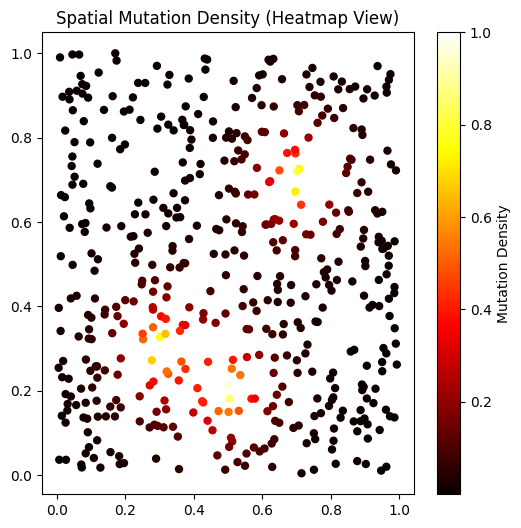

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Generate points
n_cells = 500
x = np.random.rand(n_cells)
y = np.random.rand(n_cells)

# Malignant-like mutations (clustered)
mutation_strength = np.zeros(n_cells)

cluster_centers = [(0.3, 0.3), (0.7, 0.7), (0.5, 0.2)]

for cx, cy in cluster_centers:
    distances = np.sqrt((x - cx)**2 + (y - cy)**2)
    mutation_strength += np.exp(-distances * 15)

# Normalize values
mutation_strength = mutation_strength / mutation_strength.max()

# Plot heatmap-style scatter
plt.figure(figsize=(6,6))
plt.scatter(x, y, c=mutation_strength, cmap='hot', s=25)
plt.colorbar(label="Mutation Density")
plt.title("Spatial Mutation Density (Heatmap View)")
plt.show()

## Figure 4: Comparison of Benign and Malignant Tissue

The paper highlights key differences between benign and malignant tissue in terms of mutation patterns and clonal organization.

In this simulation, both conditions are visualized side by side to emphasize these differences:

- **Benign tissue**:
  - Low mutation frequency
  - Mutations are randomly distributed
  - Minimal clustering

- **Malignant tissue**:
  - Higher mutation frequency
  - Strong spatial clustering
  - Formation of larger clonal populations

This comparison reflects the findings of the paper, where malignant tissues show complex clonal architectures and increased spatial organization of mutations, while benign tissues exhibit simpler and more scattered patterns.

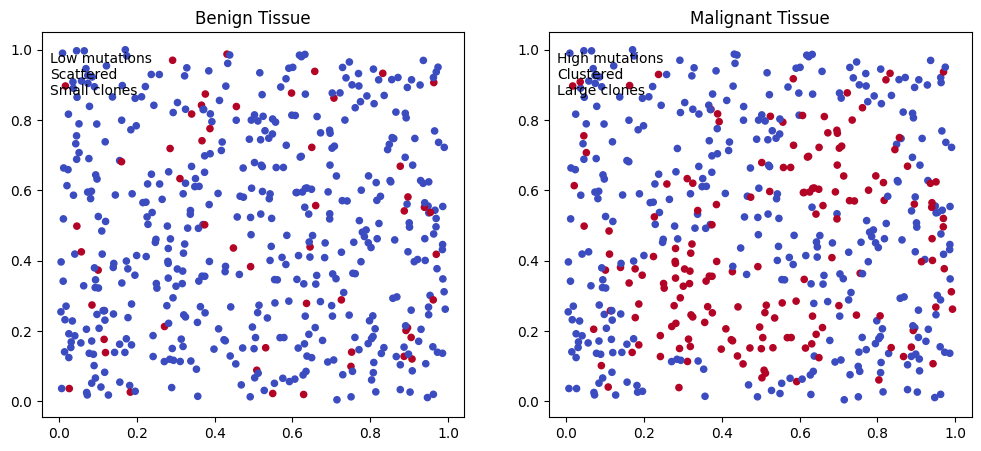

In [4]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n_cells = 500
x = np.random.rand(n_cells)
y = np.random.rand(n_cells)

# --- BENIGN ---
benign = np.random.choice([0, 1], size=n_cells, p=[0.9, 0.1])

# --- MALIGNANT ---
malignant = np.zeros(n_cells)

cluster_centers = [(0.3, 0.3), (0.7, 0.7), (0.5, 0.2)]

for cx, cy in cluster_centers:
    distances = np.sqrt((x - cx)**2 + (y - cy)**2)
    malignant[distances < 0.15] = 1

# add random mutations
noise = np.random.choice([0, 1], size=n_cells, p=[0.8, 0.2])
malignant = np.maximum(malignant, noise)

# --- PLOT ---
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Benign
axs[0].scatter(x, y, c=benign, cmap='coolwarm', s=20)
axs[0].set_title("Benign Tissue")
axs[0].text(0.02, 0.95, "Low mutations\nScattered\nSmall clones",
            transform=axs[0].transAxes, fontsize=10, verticalalignment='top')

# Malignant
axs[1].scatter(x, y, c=malignant, cmap='coolwarm', s=20)
axs[1].set_title("Malignant Tissue")
axs[1].text(0.02, 0.95, "High mutations\nClustered\nLarge clones",
            transform=axs[1].transAxes, fontsize=10, verticalalignment='top')

plt.show()